# Student Droupout Analysis


In [70]:
#importing the libaries 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

In [71]:
# Extracting dataset 

dataset = pd.read_csv("../data/student_dropout_dataset.csv")
dataset.head()

,student_id,age,region,enroll_date,exam_season,courses_enrolled,completed_assignments,completion_rate,login_frequency,last_activity_days_ago,forum_posts_count,dropout_score,label,label_multiclass,label_name
0,STU00001,26,Alexandria,2024-01-13,0,3,5,0.3571,5.29,10,5,0.1064,0,0,active
1,STU00002,23,Amman,2024-05-05,0,6,0,0.0000,0.84,7,0,0.6627,1,2,dropped
2,STU00003,17,Dubai,2024-03-12,0,3,1,0.0435,1.79,36,0,0.7299,1,2,dropped
3,STU00004,23,Alexandria,2024-12-12,0,6,13,0.4396,0.78,9,0,0.5315,1,1,at-risk
4,STU00005,20,Baghdad,2024-02-14,0,5,5,0.2078,0.92,11,0,0.7904,1,2,dropped


In [72]:
dataset.tail()

,student_id,age,region,enroll_date,exam_season,courses_enrolled,completed_assignments,completion_rate,login_frequency,last_activity_days_ago,forum_posts_count,dropout_score,label,label_multiclass,label_name
4995,STU04996,26,Baghdad,2024-07-10,0,2,7,0.6537,11.06,1,14,0.0000,0,0,active
4996,STU04997,34,Casablanca,2024-09-22,0,2,3,0.2559,5.16,15,3,0.3356,1,1,at-risk
4997,STU04998,18,Casablanca,2024-04-01,0,3,3,0.2242,5.05,5,6,0.2709,0,0,active
4998,STU04999,24,Beirut,2024-12-30,0,1,1,0.2659,4.04,1,4,0.2695,0,0,active
4999,STU05000,18,Beirut,2024-09-26,0,1,0,0.0741,3.43,1,3,0.2827,0,0,active


In [73]:
dataset.shape

(5000, 15)

In [74]:
dataset.describe()

,age,exam_season,courses_enrolled,completed_assignments,completion_rate,login_frequency,last_activity_days_ago,forum_posts_count,dropout_score,label,label_multiclass
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.0000,5000.000000,5000.000000,5000.000000,5000.000000
mean,23.736600,0.094000,3.999400,5.188400,0.260985,3.453820,9.3564,4.212200,0.431556,0.659200,0.985800
std,4.583211,0.291858,1.997348,6.109466,0.249010,3.248316,9.4361,4.270131,0.263529,0.474026,0.816904
min,17.000000,0.000000,1.000000,0.000000,0.000000,0.100000,1.0000,0.000000,0.000000,0.000000,0.000000
25%,20.000000,0.000000,2.000000,1.000000,0.053900,0.980000,2.0000,1.000000,0.204575,0.000000,0.000000
50%,24.000000,0.000000,4.000000,3.000000,0.206700,2.440000,6.0000,3.000000,0.441550,1.000000,1.000000
75%,27.000000,0.000000,6.000000,7.000000,0.389025,4.942500,13.0000,6.000000,0.658325,1.000000,2.000000
max,40.000000,1.000000,7.000000,35.000000,1.000000,14.000000,70.0000,24.000000,1.000000,1.000000,2.000000


In [75]:
dataset.dtypes

student_id                 object
age                         int64
region                     object
enroll_date                object
exam_season                 int64
courses_enrolled            int64
completed_assignments       int64
completion_rate           float64
login_frequency           float64
last_activity_days_ago      int64
forum_posts_count           int64
dropout_score             float64
label                       int64
label_multiclass            int64
label_name                 object
dtype: object

In [76]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   student_id              5000 non-null   object 
 1   age                     5000 non-null   int64  
 2   region                  5000 non-null   object 
 3   enroll_date             5000 non-null   object 
 4   exam_season             5000 non-null   int64  
 5   courses_enrolled        5000 non-null   int64  
 6   completed_assignments   5000 non-null   int64  
 7   completion_rate         5000 non-null   float64
 8   login_frequency         5000 non-null   float64
 9   last_activity_days_ago  5000 non-null   int64  
 10  forum_posts_count       5000 non-null   int64  
 11  dropout_score           5000 non-null   float64
 12  label                   5000 non-null   int64  
 13  label_multiclass        5000 non-null   int64  
 14  label_name              5000 non-null   

In [77]:
dataset.describe(include="object")

,student_id,region,enroll_date,label_name
count,5000,5000,5000,5000
unique,5000,10,365,3
top,STU05000,Doha,2024-12-04,active
freq,1,534,23,1704


In [78]:
# Checking the every column and counts how many values are missing 
dataset.isnull().sum() #another extra .sum() counts the total missing value across the entire DS

student_id                0
age                       0
region                    0
enroll_date               0
exam_season               0
courses_enrolled          0
completed_assignments     0
completion_rate           0
login_frequency           0
last_activity_days_ago    0
forum_posts_count         0
dropout_score             0
label                     0
label_multiclass          0
label_name                0
dtype: int64

As , we have no missing value in all columns 

In [79]:
# Checks if the row has any copy of another row 
dataset.duplicated().sum()


np.int64(0)

In [80]:
dataset.columns

Index(['student_id ', 'age', 'region', 'enroll_date', 'exam_season',
       'courses_enrolled', 'completed_assignments', 'completion_rate',
       'login_frequency', 'last_activity_days_ago', 'forum_posts_count',
       'dropout_score', 'label', 'label_multiclass', 'label_name'],
      dtype='object')

In [81]:
#Checking the counts of unique values in a column 
dataset['student_id '].nunique()

5000

if it was less than 5000 it would mean some students apperas twice undet the same ID

# Label Name


In [82]:
label_counts = dataset["label_name"].value_counts() # checking the how many times each category appears
print(label_counts)
print()
print(label_counts / len(dataset)*100) # Converting into percentages

label_name
active     1704
at-risk    1663
dropped    1633
Name: count, dtype: int64

label_name
active     34.08
at-risk    33.26
dropped    32.66
Name: count, dtype: float64


# Plot Target Variables

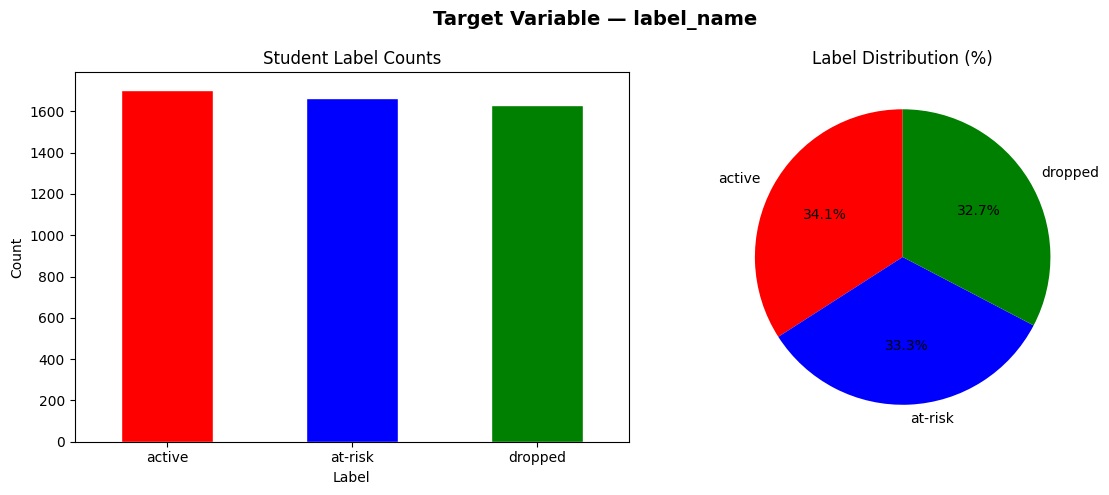

In [83]:
# Plot The Target Variables
fig, axes = plt.subplots(1, 2, figsize=(12, 5)) # Creating a two side by side plots. 

colors = ["red", "blue", "green"]

# Bar chart
label_counts.plot(kind='bar', ax=axes[0], color=colors, edgecolor='white')
axes[0].set_title('Student Label Counts')
axes[0].set_xlabel('Label')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

# Pie chart
axes[1].pie(label_counts.values, labels=label_counts.index,
     autopct='%1.1f%%', colors=colors, startangle=90)
axes[1].set_title('Label Distribution (%)')

plt.suptitle('Target Variable — label_name', fontsize=14, fontweight='bold')
plt.savefig("../outputs/01_Target Variable- Label_name.png")
plt.tight_layout()
plt.show()

As, The lable name is almost perfectly balanced with similar counts 

# Region

In [84]:
# Which region have most students

student_region = dataset["region"].value_counts()
print(student_region)

region
Doha          534
Baghdad       532
Riyadh        510
Casablanca    509
Tunis         499
Alexandria    493
Cairo         484
Dubai         482
Amman         481
Beirut        476
Name: count, dtype: int64


Doha and Baghdad have most student region count than the Beircut 

In [85]:
# Which Region Droupout with label name

std_dropout_region = dataset.groupby("region")["label_name"].value_counts().unstack()
std_dropout_region

label_name,active,at-risk,dropped
region,,,
Alexandria,193,157,143
Amman,172,155,154
Baghdad,185,168,179
Beirut,146,158,172
Cairo,168,153,163
Casablanca,157,172,180
Doha,163,190,181
Dubai,170,156,156
Riyadh,188,167,155


Alexandria region have heighest number of active student(it might be because of good teaching style and student eger to learn ) than other region where Cassablanca and Doha have the heighest number of dropped students might be of low standard quality of online class

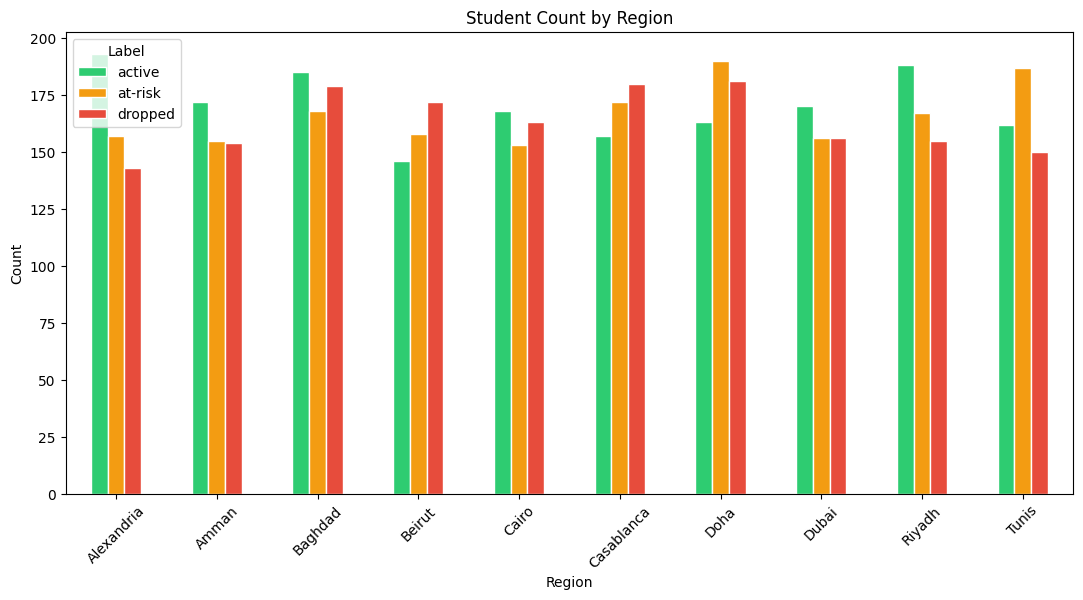

In [86]:
colors = {'active': '#2ecc71', 'at-risk': '#f39c12', 'dropped': '#e74c3c'}

std_dropout_region.plot(kind='bar', color=[colors[col] for col in std_dropout_region.columns], edgecolor='white',figsize=(13,6))
plt.title('Student Count by Region')
plt.xlabel('Region')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend(title='Label')
plt.savefig("../outputs/02_Studetn coutn by region.png")
plt.show()

# Enroll Date 

In [87]:
print(dataset['enroll_date'].dtype)
print()
print(dataset['enroll_date'].head(10))

object

0    2024-01-13
1    2024-05-05
2    2024-03-12
3    2024-12-12
4    2024-02-14
5    2024-08-04
6    2024-01-16
7    2024-04-21
8    2024-09-15
9    2024-01-14
Name: enroll_date, dtype: object


In [88]:
# Converting into proper date format
dataset['enroll_date'] = pd.to_datetime(dataset['enroll_date'])
print(dataset['enroll_date'].dtype)

datetime64[ns]


In [89]:
# Extracting the month and year
dataset['enroll_month'] = dataset['enroll_date'].dt.month # Extract just the month number (1-12)
dataset['enroll_year'] = dataset['enroll_date'].dt.year     # Extraxts just the year

print(dataset[['enroll_date', 'enroll_month', 'enroll_year']].head(10))

  enroll_date  enroll_month  enroll_year
0  2024-01-13             1         2024
1  2024-05-05             5         2024
2  2024-03-12             3         2024
3  2024-12-12            12         2024
4  2024-02-14             2         2024
5  2024-08-04             8         2024
6  2024-01-16             1         2024
7  2024-04-21             4         2024
8  2024-09-15             9         2024
9  2024-01-14             1         2024


In [90]:
#Enrollment count by their months

dataset['enroll_month'].value_counts().sort_index() #value count count how many students enrolled in each month
                                                       #sort_index sorts by month number insead of count 

enroll_month
1     390
2     430
3     421
4     388
5     418
6     436
7     418
8     451
9     388
10    422
11    386
12    452
Name: count, dtype: int64

December and August are slightly higher, possibly due to semester starts or holiday motivation.

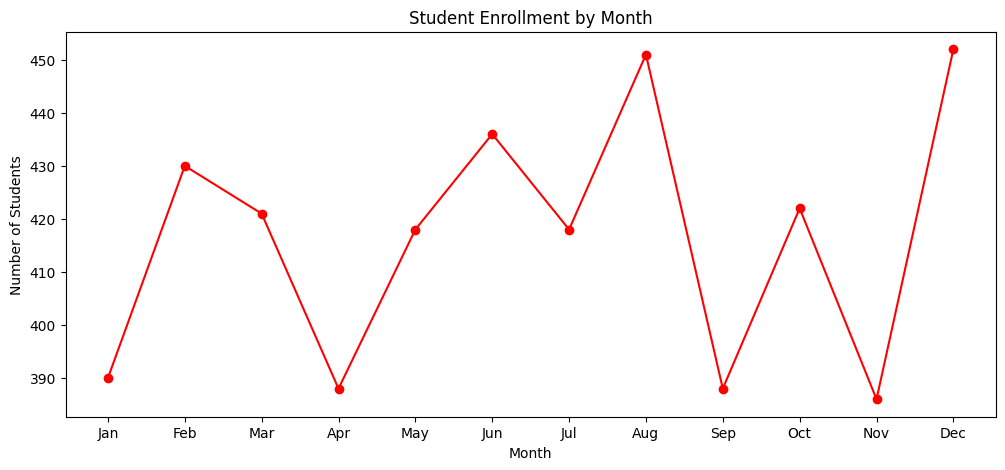

In [ ]:
# Enrollment Trend by months
dataset['enroll_month'].value_counts().sort_index().plot(kind='line', marker='o', color='red',figsize=(12,5))
plt.title('Student Enrollment by Month')
plt.xlabel('Month')
plt.ylabel('Number of Students')
plt.xticks(range(1, 13), ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']) #replaces month numbers (1–12) with actual 
plt.savefig("../outputs/03_Studetn Enrollment by month.png")

plt.show()

as jan , apr , sep , nov have the lowest number of student to enroll due to semester exam 

# Exam Season count

In [97]:
#how many student did join online class during exam season
print(dataset['exam_season'].value_counts())

exam_season
0    4530
1     470
Name: count, dtype: int64


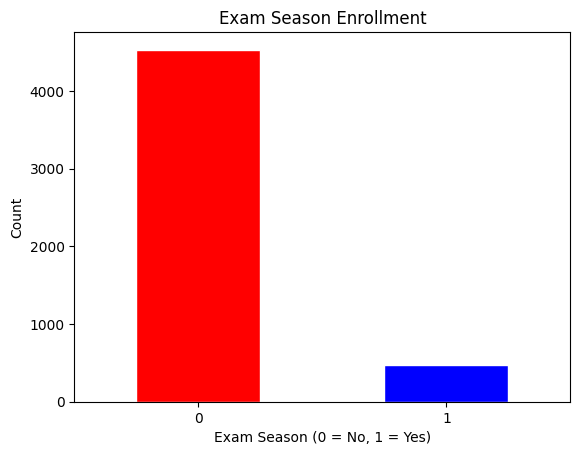

In [96]:
dataset['exam_season'].value_counts().plot(kind='bar', color=['red', 'blue'], edgecolor='white')
plt.title('Exam Season Enrollment')
plt.xlabel('Exam Season (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.savefig("../outputs/04_Exam season enrollment.png")

plt.show()

Only few student enrolled during exam season. The vast majority enrolled during normal periods.

# Course Enrolled 

In [98]:

print(dataset['courses_enrolled'].value_counts().sort_index())
print()
print(dataset['courses_enrolled'].describe())

courses_enrolled
1    724
2    706
3    704
4    703
5    726
6    752
7    685
Name: count, dtype: int64

count    5000.000000
mean        3.999400
std         1.997348
min         1.000000
25%         2.000000
50%         4.000000
75%         6.000000
max         7.000000
Name: courses_enrolled, dtype: float64


Students enroll in 1 to 7 courses, averaging exactly 4.

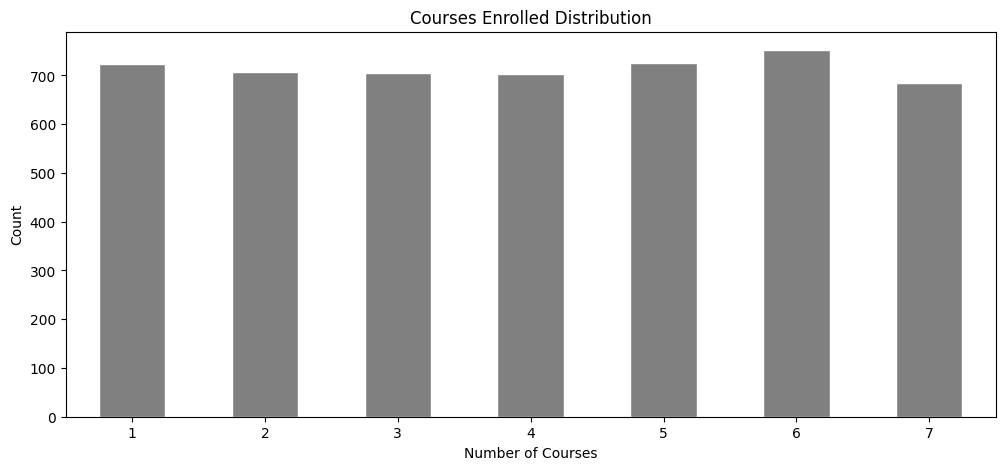

In [102]:
dataset['courses_enrolled'].value_counts().sort_index().plot(kind='bar', color='grey', edgecolor='white',figsize=(12,5))
plt.title('Courses Enrolled Distribution')
plt.xlabel('Number of Courses')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.savefig("../outputs/05_Course enrolled.png")
plt.show()

In [103]:
dataset.to_csv("../data/student backup.csv", index=False)